# 02 — Classical ML: HOG + SVM, tuning and interpretation

In [1]:
from pathlib import Path
import os
import sys

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (CURRENT, *CURRENT.parents) if (path / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root табылмады. Notebook-ты project папкасының ішінен ашыңыз."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.executable)


PROJECT_ROOT: C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu
Python: c:\Users\Ansagan\venvs\ml-yolo-cpu\Scripts\python.exe


Классикалық baseline YOLOv10 dataset-тегі bounding box crop-тарын HOG белгілеріне айналдырып, LinearSVC моделін оқытады.

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from sklearn.inspection import permutation_importance

from src.classical_baseline import train_hog_svm
from src.config import METRICS_DIR, MODELS_DIR, analysis_data_yaml
from src.yolo_dataset_utils import dataset_diagnostics

DATA_YAML = analysis_data_yaml()
MODEL_PATH = MODELS_DIR / "hog_svm_baseline.joblib"
METRICS_PATH = METRICS_DIR / "hog_svm_metrics.json"
print("HOG + SVM dataset:", DATA_YAML)
display(dataset_diagnostics(DATA_YAML))


c:\Users\Ansagan\venvs\ml-yolo-cpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HOG + SVM dataset: C:\Users\Ansagan\Downloads\smart_vision_final_project_laptop_cpu\outputs\runtime\yolov10\data_runtime.yaml


,split,resolved_path,path_exists,images,label_files,objects,missing_label_examples
0,train,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,True,3752,3752,4366,
1,val,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,True,938,938,1047,
2,test,C:\Users\Ansagan\Documents\Ansagan\Ansagan\dat...,True,938,938,1047,


In [3]:
# Жылдам тексеру: 100. Финалдық нәтиже: 300–500.
MAX_SAMPLES_PER_CLASS = 50

model, metrics, split_data = train_hog_svm(
    data_yaml=DATA_YAML,
    output_model=MODEL_PATH,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
)
X_train, X_test, y_train, y_test = split_data
METRICS_PATH.write_text(
    json.dumps(metrics, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
summary = {
    key: value
    for key, value in metrics.items()
    if key not in {"classification_report", "confusion_matrix"}
}
print(json.dumps(summary, indent=2, ensure_ascii=False))


HOG class 19: 100%|██████████| 50/50 [00:00<00:00, 52.80object/s]


Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ........................................svc__C=0.01; total time=   4.6s
[CV] END ........................................svc__C=0.01; total time=   5.3s
[CV] END ........................................svc__C=0.01; total time=   5.2s
[CV] END .........................................svc__C=0.1; total time=   6.1s
[CV] END .........................................svc__C=0.1; total time=   5.7s
[CV] END .........................................svc__C=0.1; total time=   5.3s
[CV] END .........................................svc__C=1.0; total time=   6.6s
[CV] END .........................................svc__C=1.0; total time=   4.6s
[CV] END .........................................svc__C=1.0; total time=   4.4s
[CV] END ........................................svc__C=10.0; total time=   4.1s
[CV] END ........................................svc__C=10.0; total time=   5.3s
[CV] END ........................................

{'person': {'precision': 0.8888888888888888,
  'recall': 0.9411764705882353,
  'f1-score': 0.9142857142857143,
  'support': 17.0},
 'velo': {'precision': 1.0,
  'recall': 0.8333333333333334,
  'f1-score': 0.9090909090909091,
  'support': 6.0},
 'basty': {'precision': 0.8571428571428571,
  'recall': 0.8571428571428571,
  'f1-score': 0.8571428571428571,
  'support': 7.0},
 'belgisiz': {'precision': 0.7692307692307693,
  'recall': 1.0,
  'f1-score': 0.8695652173913043,
  'support': 10.0},
 'car': {'precision': 1.0,
  'recall': 0.9166666666666666,
  'f1-score': 0.9565217391304348,
  'support': 12.0},
 'belgi1': {'precision': 0.8181818181818182,
  'recall': 1.0,
  'f1-score': 0.9,
  'support': 9.0},
 'belgi2': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 10.0},
 'belgi3': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 10.0},
 'belgi4': {'precision': 1.0,
  'recall': 0.7333333333333333,
  'f1-score': 0.8461538461538461,
  'support': 15.0},
 'belgi5': {'precisi

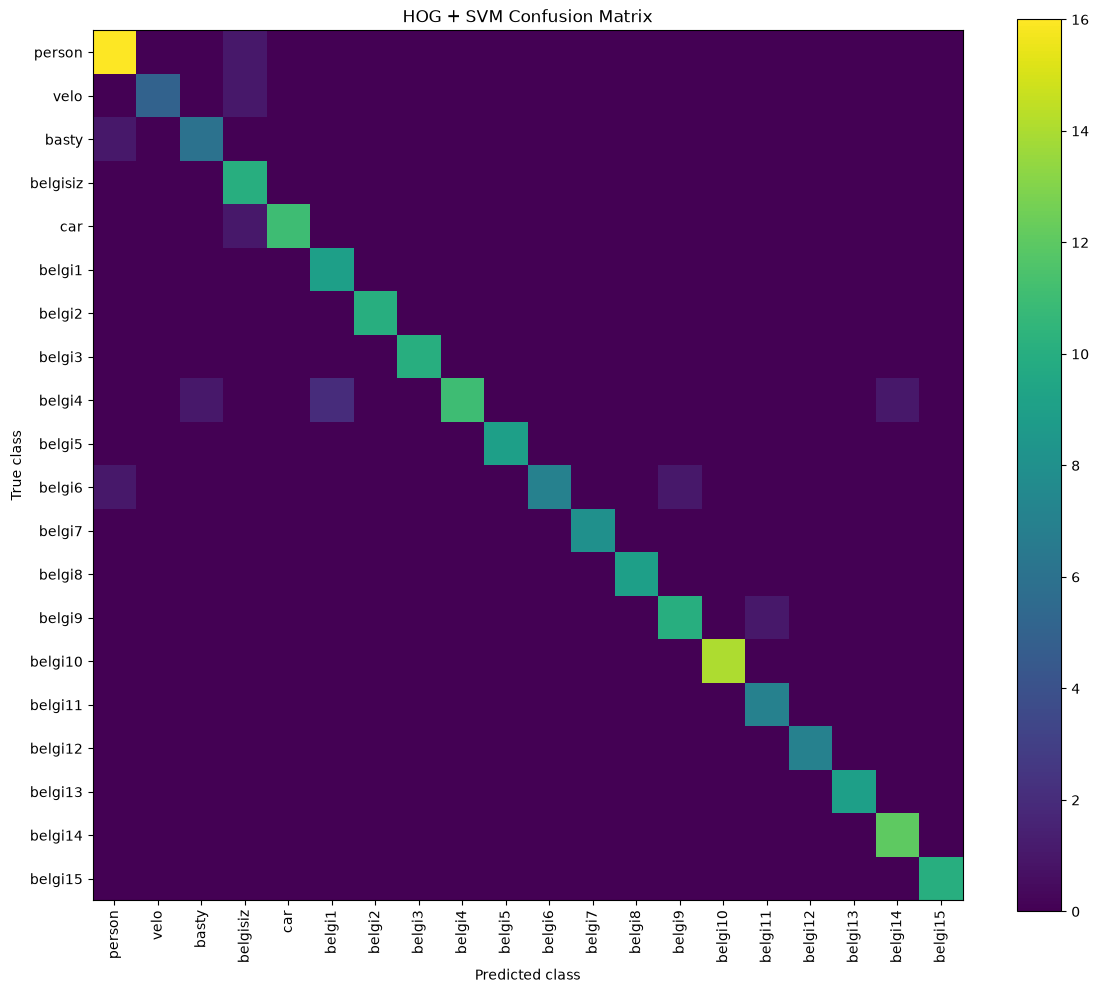

In [4]:
display(metrics["classification_report"])

confusion = np.asarray(metrics["confusion_matrix"])
class_names = metrics["class_names"]
plt.figure(figsize=(12, 10))
plt.imshow(confusion)
plt.title("HOG + SVM Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()


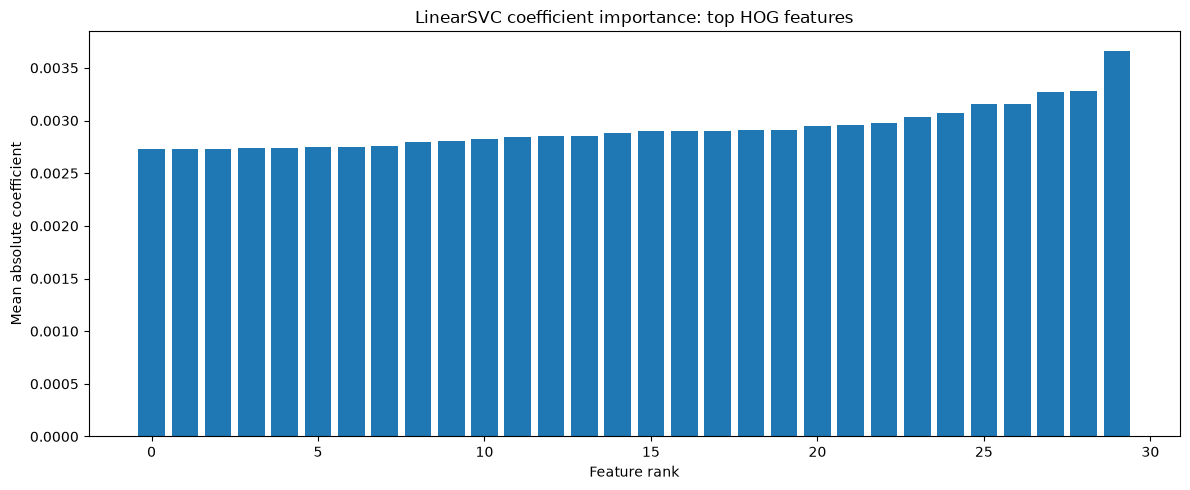

In [5]:
svc = model.named_steps["svc"]
coefficient_importance = np.mean(np.abs(svc.coef_), axis=0)
top_indices = np.argsort(coefficient_importance)[-30:]
plt.figure(figsize=(12, 5))
plt.bar(range(len(top_indices)), coefficient_importance[top_indices])
plt.title("LinearSVC coefficient importance: top HOG features")
plt.xlabel("Feature rank")
plt.ylabel("Mean absolute coefficient")
plt.tight_layout()
plt.show()


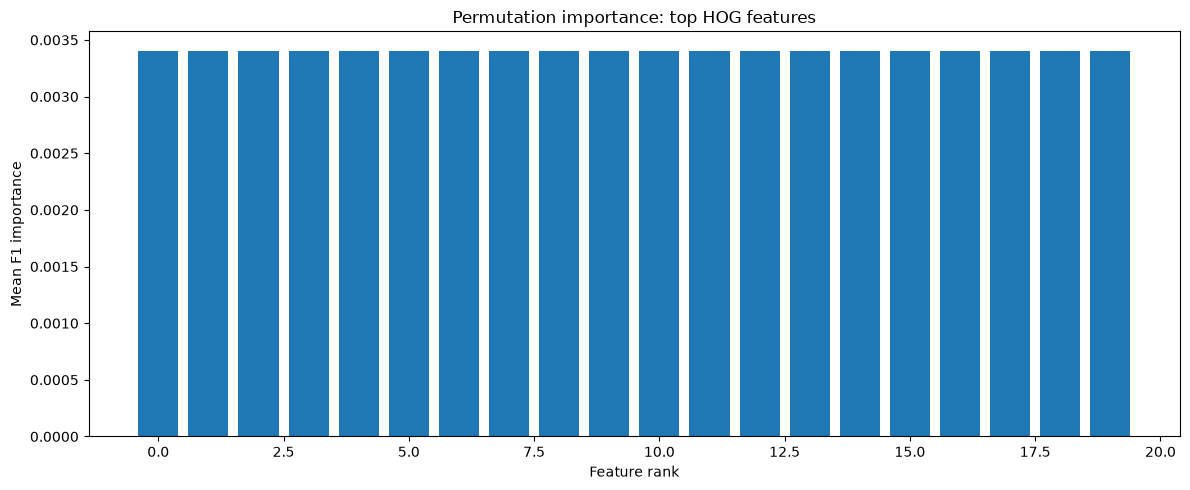

In [6]:
sample_count = min(150, len(X_test))
permutation_result = permutation_importance(
    estimator=model,
    X=X_test[:sample_count],
    y=y_test[:sample_count],
    n_repeats=2,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1,
)
top_indices = np.argsort(permutation_result.importances_mean)[-20:]
plt.figure(figsize=(12, 5))
plt.bar(range(len(top_indices)), permutation_result.importances_mean[top_indices])
plt.title("Permutation importance: top HOG features")
plt.xlabel("Feature rank")
plt.ylabel("Mean F1 importance")
plt.tight_layout()
plt.show()


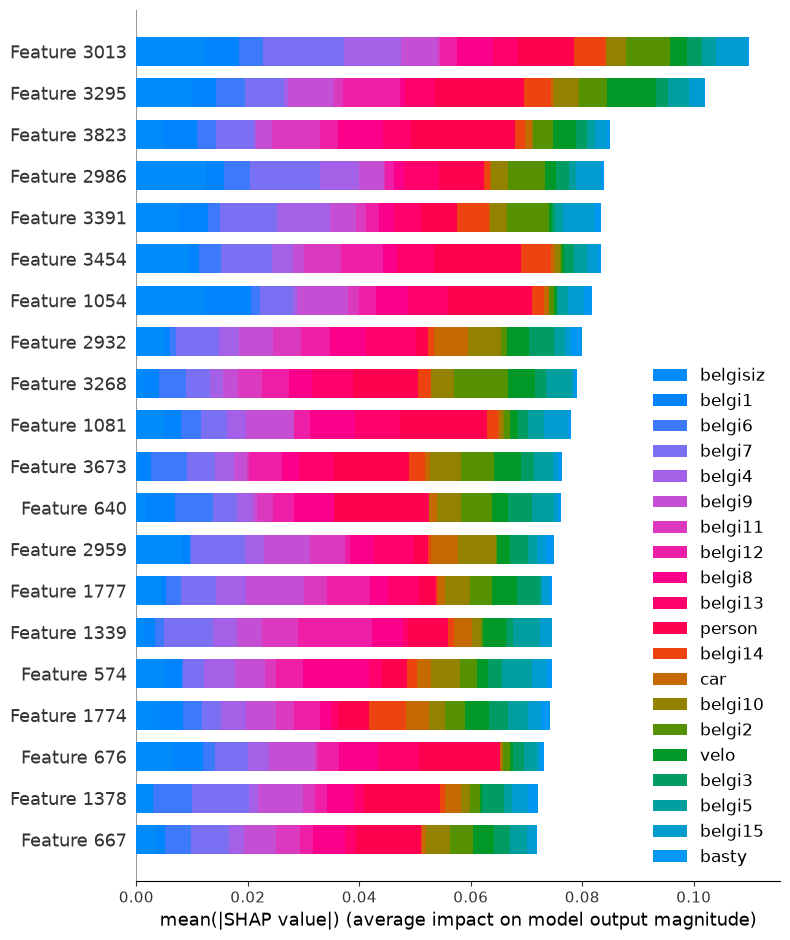

In [7]:
try:
    import shap

    scaler = model.named_steps["scaler"]
    svc = model.named_steps["svc"]
    background = scaler.transform(X_train[: min(50, len(X_train))])
    explained = scaler.transform(X_test[: min(20, len(X_test))])
    explainer = shap.LinearExplainer(svc, background)
    shap_result = explainer(explained)
    shap_values = shap_result.values
    if shap_values.ndim == 3:
        values_by_class = [
            shap_values[:, :, class_index]
            for class_index in range(shap_values.shape[2])
        ]
        shap.summary_plot(
            values_by_class,
            explained,
            class_names=metrics["class_names"],
            max_display=20,
            show=True,
        )
    else:
        shap.summary_plot(shap_values, explained, max_display=20, show=True)
except (ImportError, ValueError, RuntimeError, TypeError, AttributeError) as error:
    print("SHAP visualization жасалмады:", repr(error))
